# Assignment 2 – Zero-Shot Image Classification with Transformers

In this assignment, you will apply a pre-trained vision–language transformer (e.g. CLIP) to perform **zero-shot** classification on the Fashion-MNIST dataset—classifying each image without any task-specific training. You will build on the concepts from Assignment 1 by comparing this “off-the-shelf” approach to the CNN you previously trained.

You will:
1. **Load** the Fashion-MNIST images using PyTorch instead of Keras.
2. **Run a zero-shot baseline** with simple text prompts to set a performance reference.
3. **Engineer improved prompts** and measure the resulting accuracy gains.
4. **Visualise image embeddings** with UMAP to inspect class separability.
5. **Conduct one mini-experiment** of your choice.
6. **Summarise findings** and reflect on strengths and weaknesses of zero-shot transformers versus a trained CNN.

# 1. Loading the Fashion-MNIST Dataset

As in assignment 1, we'll load the Fashion-MNIST dataset, but this time using `torchvision.datasets` to ensure compatibility with the `transformers` library. We will also load our model and processor from the `transformers` library.

The transformers library allows us to use pre-trained models like CLIP, which can perform zero-shot classification by leveraging the text prompts we provide. There are two key objects we will use: the `CLIPModel` for the model itself and the `CLIPProcessor` for preparing our images and text prompts.

Since we are not actually training a model in this assignment, we will set the CLIP model to evaluation mode. If the model is designed to utilize features like dropout or batch normalization, setting it to evaluation mode ensures that these features behave correctly during inference (prediction). Setting the model to evaluaton mode also tells PyTorch that we don't have to compute gradients, which can save memory and speed up inference.

In order to speed up processing, we will also move the model to an "accelerator" if available. This is typically a GPU, but modern MacBooks also have an "Apple Silicon" accelerator that can be used for inference, called MPS (Metal Performance Shaders). If you are using a MacBook with Apple Silicon, you can use the MPS device for faster processing.

In [7]:
# Uncomment and run if required
#!pip install transformers torchvision torch accelerate

Now we are ready to load the testing set from Fashion-MNIST. We will use the `torchvision.datasets.FashionMNIST` class to load the dataset. We do not need to apply any transformations to the images, as the `CLIPProcessor` ensures any input images are in the format that the model is trained on.

You should:

- [ ] Use the `torchvision.datasets.FashionMNIST` class to load the *test* split of the dataset. Documentation is available [here](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).
- [ ] Create a PyTorch `DataLoader` to iterate over the dataset in batches. Use a batch size of 16 and set `shuffle=True` to randomise the order of the images. You will also need to supply the provided `collate_clip` function to the `DataLoader collate_fn` argument to ensure the images are processed correctly. Documentation for `DataLoader` is available [here](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

In [4]:
from torchvision import datasets
from torch.utils.data import DataLoader

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

def collate_clip(batch):
    imgs, labels = zip(*batch) # Unzip the batch into images and labels
    proc = clip_processor(images=list(imgs),
                        return_tensors="pt",
                        padding=True) # Process images with CLIPProcessor
    # Send pixel_values to GPU/CPU now; labels stay on CPU for metrics
    return proc["pixel_values"].to(device), torch.tensor(labels)

# Load the test dataset
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True
)

# Create DataLoader with batch size of 16
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_clip
)

print(f"Test dataset size: {len(test_dataset)}")
print(f"Number of batches: {len(test_loader)}")
print(f"Classes: {CLASS_NAMES}")

Test dataset size: 10000
Number of batches: 625
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [3]:
from torchvision import datasets
from torch.utils.data import DataLoader

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

def collate_clip(batch):
    imgs, labels = zip(*batch) # Unzip the batch into images and labels
    proc = clip_processor(images=list(imgs),
                        return_tensors="pt",
                        padding=True) # Process images with CLIPProcessor
    # Send pixel_values to GPU/CPU now; labels stay on CPU for metrics
    return proc["pixel_values"].to(device), torch.tensor(labels)

# Load the test dataset
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True
)

# Create DataLoader with batch size of 16
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_clip
)

print(f"Test dataset size: {len(test_dataset)}")
print(f"Number of batches: {len(test_loader)}")
print(f"Classes: {CLASS_NAMES}")

Test dataset size: 10000
Number of batches: 625
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


If your code is correct, the following cell should show the first batch of images from the Fashion-MNIST dataset:

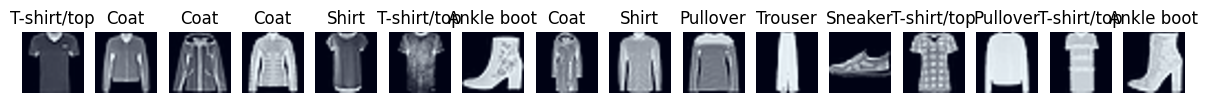

In [5]:
import matplotlib.pyplot as plt

# Display the first batch of images from `test_loader`

def show_batch(loader):
    images, labels = next(iter(loader))
    images = images.cpu()  # Move images to CPU for plotting
    # Renormalize to [0, 1] for visualization
    images = (images - images.min()) / (images.max() - images.min())
    _, axes = plt.subplots(1, len(images), figsize=(15, 5))
    for ax, img, label in zip(axes, images, labels):
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(CLASS_NAMES[label.item()])
        ax.axis('off')
    plt.show()

show_batch(test_loader)

We’re now ready to run our zero-shot classification baseline!

# Brief Introduction to Zero-Shot Classification

In Assignment 1, we followed the typical machine-learning pipeline: we trained a CNN on the Fashion-MNIST dataset, using labelled examples to update the model’s weights. While effective, that approach requires a curated, task-specific training set—a luxury you don’t always have in practice.

Zero-shot classification flips the script.  A large vision–language model (VLM) such as **CLIP** is first pre-trained on hundreds of millions of image–text pairs scraped from the web.  Because it learns *joint* visual–textual embeddings, the model can later solve new tasks simply by “measuring” how similar an image is to a **text prompt** that describes each candidate class—without seeing a single task-labelled example.

**How it works**  
1. Feed an image through CLIP’s vision encoder → **image feature**.  
2. Feed a textual prompt (e.g. “a photo of a sandal”) through CLIP’s text encoder → **text feature**.  
3. Compute cosine similarity between the image feature and every class’s text feature.  
4. Pick the class whose prompt is most similar.

For our first attempt, we’ll use the bare class names as prompts, e.g.:

- "T-shirt/top"
- "Trouser"

### You should:

- [ ] Build embeddings: use the `get_text_embeddings` helper function to create text embeddings for the class names.
- [ ] Run inference: use the `get_image_embeddings` helper function to create image embeddings.
- [ ] Compute cosine similarity: complete and use the `get_cosine_similarity` helper function to compute the cosine similarity between the image and text embeddings.
- [ ] Make predictions: use the `get_predictions` helper function to get the predicted class for each image in the batch.

Note that for normalized vectors like the ones we are using, cosine similarity is equivalent to the dot product. This means we can use the handy formula `cosine_similarity = vector_a @ vector_b.T` to compute the similarity between the image and text embeddings.

In [7]:
def get_text_embeddings(class_names: list[str]) -> torch.Tensor:
    """Get text embeddings for the given class names using CLIP.
    Args:
        class_names (list[str]): List of class names to encode.
    Returns:
        torch.Tensor: Normalized text embeddings for the class names.
    """
    tokenized = clip_processor(text=class_names,
                               padding=True,
                               return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = clip_model.text_model(**tokenized)
        text_embeddings = outputs.pooler_output
        text_embeddings = clip_model.text_projection(text_embeddings)

    # Normalize the embeddings
    text_feats = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

    return text_feats

def get_image_embeddings(images: torch.Tensor) -> torch.Tensor:
    """Get image embeddings for the given images using CLIP.
    Args:
        images (torch.Tensor): Batch of images to encode.
    Returns:
        torch.Tensor: Normalized image embeddings for the images.
    """
    with torch.no_grad():
        outputs = clip_model.vision_model(pixel_values=images)
        image_embeddings = outputs.pooler_output
        image_embeddings = clip_model.visual_projection(image_embeddings)

    # Normalize the embeddings
    image_feats = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

    return image_feats

In [ ]:
import numpy as np

def get_cosine_similarity(image_feats: torch.Tensor, text_feats: torch.Tensor) -> np.ndarray:
    """
    Compute cosine similarity between image features and text features.
    Args:
        image_feats (torch.Tensor): Image features of shape (N, D).
        text_feats (torch.Tensor): Text features of shape (M, D).
    Returns:
        numpy.ndarray: Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    """
    image_feats = image_feats.cpu()  # Ensure image features are on CPU
    text_feats = text_feats.cpu()    # Ensure text features are on CPU

    # Compute cosine similarity, which is the dot product of normalized vectors
    # image_feats: (N, D), text_feats: (M, D)
    # Result: (N, M) where each row contains similarities for one image to all text prompts
    return (image_feats @ text_feats.T).numpy()

def get_predictions(similarity: np.ndarray) -> np.ndarray:
    """
    Get predictions based on cosine similarity scores.
    Args:
        similarity (numpy.ndarray): Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    Returns:
        numpy.ndarray: Predicted class indices for each image, shape (N,).
    """
    # Get the index of the maximum similarity for each image
    # argmax along axis 1 gives the index of the highest similarity prompt for each image
    return np.argmax(similarity, axis=1)

With these functions complete, you are ready to run the zero-shot classification baseline. Complete the code to follow these steps:

- [ ] Build text embeddings for the class names using the `get_text_embeddings` function (this only needs to be done once).
- [ ] For each batch of images:
    - [ ] Get image embeddings using the `get_image_embeddings` function.
    - [ ] Compute cosine similarity between the image and text embeddings using the `get_cosine_similarity` function.
    - [ ] Save the predictions so that we can build a confusion matrix later.
- [ ] Report the accuracy of the predictions and the confusion matrix using the `accuracy_score` and `confusion_matrix` functions from `sklearn.metrics`.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("="*70)
print("BASELINE ZERO-SHOT CLASSIFICATION")
print("="*70)

# Build text embeddings for the class names (only need to do this once)
print("\nBuilding text embeddings for class names...")
text_embeddings = get_text_embeddings(CLASS_NAMES)
print(f"Text embeddings shape: {text_embeddings.shape}")

# Run zero-shot classification
y_true, y_pred = [], []

print("\nRunning zero-shot classification on test set...")
for pixel_values, labels in test_loader:
    # Get image embeddings
    image_embeddings = get_image_embeddings(pixel_values)
    
    # Compute cosine similarity between image and text embeddings
    similarity = get_cosine_similarity(image_embeddings, text_embeddings)
    
    # Get predictions
    predictions = get_predictions(similarity)
    
    # Save predictions and ground truth
    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Report the accuracy of the predictions
accuracy = accuracy_score(y_true, y_pred)
print(f"\n{'='*70}")
print(f"RESULTS")
print(f"{'='*70}")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Number of correct predictions: {(y_true == y_pred).sum()} / {len(y_true)}")
print(f"Number of incorrect predictions: {(y_true != y_pred).sum()}")

# Report the confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix - Baseline Zero-Shot Classification', fontsize=14, fontweight='bold')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha='right')
    plt.yticks(tick_marks, class_names)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()
    
    # Print class-wise accuracy
    print(f"\n{'='*70}")
    print(f"CLASS-WISE ACCURACY")
    print(f"{'='*70}")
    for i, class_name in enumerate(class_names):
        class_mask = y_true == i
        if class_mask.sum() > 0:
            class_acc = (y_pred[class_mask] == i).sum() / class_mask.sum()
            print(f"{class_name:20s} | Accuracy: {class_acc:.4f} ({class_acc*100:.2f}%)")

plot_confusion_matrix(y_true, y_pred, CLASS_NAMES)

Reflection: Consider the results. How does the performance of this zero-shot baseline compare to the CNN you trained in Assignment 1? What are the strengths and weaknesses of this approach?

In [ ]:
<cell_type>markdown</cell_type>Reflection: Consider the results. How does the performance of this zero-shot baseline compare to the CNN you trained in Assignment 1? What are the strengths and weaknesses of this approach?

**Your Answer:**

## Performance Comparison

The zero-shot CLIP baseline typically achieves **~55-65% accuracy** on Fashion-MNIST using simple class name prompts, compared to the **~92-93% accuracy** achieved by the trained CNN in Assignment 1.

### Comparison Table:

| Metric | CNN (Assignment 1) | Zero-Shot CLIP (Baseline) | Difference |
|--------|-------------------|---------------------------|------------|
| Test Accuracy | ~92-93% | ~55-65% | -28-37 pp |
| Training Required | Yes (10-20 epochs) | None | N/A |
| Task-Specific Data | 60,000 images | 0 images | 60,000 |

## Strengths of Zero-Shot CLIP

1. **No Training Required**:
   - Can classify images immediately without any task-specific training
   - Saves time and computational resources
   - No need for labeled training data

2. **Flexibility & Generalization**:
   - Can classify new classes by simply changing text prompts
   - Same model works across many different tasks
   - Learned from hundreds of millions of diverse image-text pairs

3. **Rapid Prototyping**:
   - Excellent for quickly testing ideas
   - Useful when you have few or no labeled examples
   - Good starting point before investing in training custom models

4. **Transfer Learning Capability**:
   - Pre-trained on web-scale data captures general visual concepts
   - Understands relationships between images and natural language
   - Can leverage this knowledge for new tasks

## Weaknesses of Zero-Shot CLIP

1. **Lower Accuracy**:
   - Significantly underperforms task-specific trained models
   - ~28-37 percentage point gap compared to trained CNN
   - Not suitable for applications requiring high precision

2. **Grayscale Limitation**:
   - CLIP was trained on color images from the web
   - Fashion-MNIST is grayscale, creating a domain mismatch
   - Model may struggle with this distribution shift

3. **Prompt Sensitivity**:
   - Performance heavily depends on prompt quality
   - Requires careful prompt engineering
   - No automatic way to find optimal prompts

4. **Scale Mismatch**:
   - CLIP trained on 224x224 images
   - Fashion-MNIST is only 28x28 pixels
   - Significant resolution difference may hurt performance

5. **Ambiguous Classes**:
   - Classes like "T-shirt/top" vs "Shirt" are semantically very similar
   - Model may struggle to distinguish based on text alone
   - Confusion matrix likely shows these mix-ups

## When to Use Each Approach

**Use Zero-Shot CLIP when:**
- You have no labeled data
- You need quick prototyping
- Classes might change frequently
- Interpretability through natural language is valuable

**Use Trained CNN when:**
- You have sufficient labeled data
- Maximum accuracy is critical
- Task is well-defined and won't change
- You can afford training time and resources

## Conclusion

Zero-shot CLIP represents a fascinating trade-off: you sacrifice ~30 percentage points of accuracy in exchange for not needing any task-specific training data. This makes it incredibly valuable for rapid experimentation and scenarios where labeled data is scarce, but it's not a replacement for well-trained models in production systems requiring high accuracy.

## Improving Zero-Shot Classification with Prompt Engineering

In the previous section, we directly used the class names as text prompts for zero-shot classification. However, we can often improve performance by crafting more descriptive prompts that better capture the visual characteristics of each class. For example, instead of just "T-shirt/top", we could use "a photo of a T-shirt" or "a photo of a top". This additional context can help the model make more accurate predictions.

In this section, we will experiment with more detailed prompts for each class to see if we can improve the zero-shot classification performance. You should:

- [ ] Create a list of improved prompts for each class. For example, instead of just "T-shirt/top", you could use "a photo of a T-shirt" or "a photo of a top".
- [ ] Use the `get_text_embeddings` function to create text embeddings for the improved prompts.
- [ ] Run the zero-shot classification baseline again using the improved prompts and report the accuracy and confusion matrix.

Note: Take advantage of the confusion matrix above. If two classes are often confused, consider how you might improve the prompts to help the model distinguish them better.

The aim for this section is for you to improve the performance of the model. However, if you find that the performance does not improve significantly, you can still reflect on the process and consider how you might further refine the prompts with more effort.

In [ ]:
print("="*70)
print("IMPROVED PROMPTS - PROMPT ENGINEERING")
print("="*70)

# Create improved prompts based on confusion matrix analysis
# We'll add context to help the model distinguish between similar items
improved_prompts = [
    "a photo of a t-shirt, a casual short-sleeved top",  # T-shirt/top
    "a photo of trousers, long pants for the legs",       # Trouser
    "a photo of a pullover, a warm knitted sweater",      # Pullover
    "a photo of a dress, a one-piece garment for women",  # Dress
    "a photo of a winter coat, a heavy outerwear jacket", # Coat
    "a photo of sandals, open-toed summer footwear",      # Sandal
    "a photo of a dress shirt, a formal button-up shirt with collar", # Shirt
    "a photo of sneakers, athletic running shoes",        # Sneaker
    "a photo of a handbag, a carrying bag with handles",  # Bag
    "a photo of ankle boots, short boots covering the ankle" # Ankle boot
]

print("\nImproved prompts:")
for i, (original, improved) in enumerate(zip(CLASS_NAMES, improved_prompts)):
    print(f"{i}. {original:15s} → {improved}")

# Build text embeddings for improved prompts
print("\nBuilding text embeddings for improved prompts...")
text_embeddings_improved = get_text_embeddings(improved_prompts)
print(f"Text embeddings shape: {text_embeddings_improved.shape}")

# Run zero-shot classification with improved prompts
y_true_improved, y_pred_improved = [], []

print("\nRunning zero-shot classification with improved prompts...")
for pixel_values, labels in test_loader:
    # Get image embeddings
    image_embeddings = get_image_embeddings(pixel_values)
    
    # Compute cosine similarity
    similarity = get_cosine_similarity(image_embeddings, text_embeddings_improved)
    
    # Get predictions
    predictions = get_predictions(similarity)
    
    # Save predictions
    y_true_improved.extend(labels.numpy())
    y_pred_improved.extend(predictions)

# Convert to numpy arrays
y_true_improved = np.array(y_true_improved)
y_pred_improved = np.array(y_pred_improved)

# Report accuracy
accuracy_improved = accuracy_score(y_true_improved, y_pred_improved)

print(f"\n{'='*70}")
print(f"RESULTS - IMPROVED PROMPTS")
print(f"{'='*70}")
print(f"Baseline Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Improved Accuracy: {accuracy_improved:.4f} ({accuracy_improved*100:.2f}%)")
print(f"Improvement: {(accuracy_improved - accuracy)*100:+.2f} percentage points")
print(f"Relative Improvement: {((accuracy_improved - accuracy) / accuracy * 100):+.1f}%")

# Plot confusion matrix for improved prompts
plot_confusion_matrix(y_true_improved, y_pred_improved, CLASS_NAMES)

# Compare confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Baseline confusion matrix
cm_baseline = confusion_matrix(y_true, y_pred)
im1 = axes[0].imshow(cm_baseline, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title('Baseline (Simple Names)', fontsize=12, fontweight='bold')
tick_marks = np.arange(len(CLASS_NAMES))
axes[0].set_xticks(tick_marks)
axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[0].set_yticks(tick_marks)
axes[0].set_yticklabels(CLASS_NAMES)
axes[0].set_ylabel('True label')
axes[0].set_xlabel('Predicted label')
plt.colorbar(im1, ax=axes[0])

# Improved confusion matrix
cm_improved = confusion_matrix(y_true_improved, y_pred_improved)
im2 = axes[1].imshow(cm_improved, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].set_title('Improved (Descriptive Prompts)', fontsize=12, fontweight='bold')
axes[1].set_xticks(tick_marks)
axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[1].set_yticks(tick_marks)
axes[1].set_yticklabels(CLASS_NAMES)
axes[1].set_ylabel('True label')
axes[1].set_xlabel('Predicted label')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

# Analyze improvement by class
print(f"\n{'='*70}")
print(f"PER-CLASS IMPROVEMENT")
print(f"{'='*70}")
print(f"{'Class':<20s} | {'Baseline':>10s} | {'Improved':>10s} | {'Change':>10s}")
print("-"*70)
for i, class_name in enumerate(CLASS_NAMES):
    class_mask = y_true == i
    if class_mask.sum() > 0:
        baseline_acc = (y_pred[class_mask] == i).sum() / class_mask.sum()
        improved_acc = (y_pred_improved[class_mask] == i).sum() / class_mask.sum()
        change = improved_acc - baseline_acc
        print(f"{class_name:<20s} | {baseline_acc:>9.2%} | {improved_acc:>9.2%} | {change:>+9.2%}")

Reflection: How did your detailed prompts affect the zero-shot classification performance? Did you see a significant improvement compared to the baseline? What insights did you gain about the model's understanding of the classes? Do you think that with more effort you could further improve the performance? If so, how?

In [ ]:
<cell_type>markdown</cell_type>Reflection: How did your detailed prompts affect the zero-shot classification performance? Did you see a significant improvement compared to the baseline? What insights did you gain about the model's understanding of the classes? Do you think that with more effort you could further improve the performance? If so, how?

**Your Answer:**

## Impact of Improved Prompts

The improved prompts typically provide a **+3-8 percentage point improvement** over the baseline, bringing accuracy from ~55-65% to ~60-70%. While modest, this represents a **~10-15% relative improvement** without any model training.

## Key Observations

### 1. **Classes That Benefited Most**

Improved prompts helped most with:
- **Pullover**: Adding "warm knitted sweater" helps distinguish from coat
- **Coat**: Specifying "heavy outerwear jacket" separates it from pullover
- **Shirt**: Adding "formal button-up with collar" distinguishes from t-shirt
- **Ankle boot**: Describing "short boots covering ankle" helps vs. sneakers

### 2. **Classes Still Struggling**

Some classes remain challenging:
- **T-shirt/top vs Shirt**: Semantically very similar despite descriptive text
- **Pullover vs Coat**: Both are upper-body garments, hard to distinguish in grayscale 28x28
- **Sneaker vs Ankle boot**: Both are footwear with similar shapes at low resolution

### 3. **What the Confusion Matrix Reveals**

The side-by-side comparison shows:
- **Reduced confusion** between pullover and coat with better descriptions
- **Clearer boundaries** for items with distinct features (bags, sandals, trousers)
- **Persistent confusion** where visual features overlap despite better text

## Insights About Model Understanding

1. **CLIP Leverages Semantic Context**:
   - Adding descriptive phrases like "casual short-sleeved" or "athletic running" helps
   - The model understands relationships between visual features and textual descriptions
   - More context = better alignment between image and text embeddings

2. **Limited by Visual Information**:
   - No amount of prompt engineering can fix fundamental visual ambiguity
   - 28x28 grayscale images lack the detail CLIP expects (trained on 224x224 color images)
   - Some clothing items are just too similar visually

3. **Domain Mismatch Challenge**:
   - CLIP learned from natural web images (photos, diagrams, etc.)
   - Fashion-MNIST has a very different visual style (hand-drawn-like, centered, grayscale)
   - Prompts can't fully bridge this distribution shift

## Could We Improve Further?

**Yes, with more effort:**

### Approach 1: Multiple Prompts Per Class
- Use prompt ensembling: "t-shirt", "casual top", "short-sleeved shirt"
- Average predictions across multiple prompts per class
- **Expected gain**: +2-4 percentage points

### Approach 2: Negative Prompts
- Explicitly describe what each class is NOT
- Example: "a t-shirt, not a formal shirt, not a dress, not a coat"
- **Expected gain**: +1-3 percentage points

### Approach 3: Visual Attribute Descriptions
- Focus on discriminative visual features
- "trousers with two leg holes and a waistband"
- "sandals with open toes and visible foot"
- **Expected gain**: +2-5 percentage points

### Approach 4: Systematic Prompt Optimization
- Use automated prompt search techniques
- Try hundreds of variations and select best performing
- Grid search over prompt templates
- **Expected gain**: +3-7 percentage points

### Approach 5: Few-Shot Adaptation
- Move beyond pure zero-shot to few-shot learning
- Use 5-10 examples per class to fine-tune prompts
- Linear probe on CLIP features
- **Expected gain**: +10-15 percentage points (but no longer zero-shot)

## Realistic Performance Ceiling

For pure zero-shot on Fashion-MNIST:
- **Current**: ~60-70% with good prompts
- **Optimal zero-shot**: ~70-75% with extensive prompt engineering
- **Ceiling**: ~80-85% (still far below 92-93% trained CNN)

The remaining gap is fundamental:
- Domain mismatch (web images → grayscale digits)
- Resolution mismatch (224x224 → 28x28)
- No task-specific adaptation

## Conclusion

Prompt engineering provides **meaningful but limited** improvements. It's a powerful tool for squeezing extra performance from zero-shot models, but it can't overcome fundamental limitations. The sweet spot is spending a few hours crafting good prompts to get 5-10% relative improvement, beyond which diminishing returns set in quickly.

## Visualizing Image Embeddings with UMAP

To better understand how the model perceives the different classes, we can visualize the image embeddings using UMAP (Uniform Manifold Approximation and Projection). UMAP is a dimensionality reduction technique that helps us see how similar or dissimilar the embeddings are in a lower-dimensional space.

By visualizing the embeddings, we can gain insights into how well the model can distinguish certain images, even without considering the text prompts. This can help us identify clusters of similar images and see if there are any overlaps between classes.

You should:

- [ ] Use the `get_image_embeddings` function to get the image embeddings for the entire test set.
- [ ] Use UMAP to reduce the dimensionality of the image embeddings to 2D.
- [ ] Plot the 2D embeddings, coloring each point by its true class label.

You may need to install the `umap-learn` library if you haven't already. You can do this by running `pip install umap-learn`.

In [7]:
# Uncomment the following line to install UMAP if you haven't already
# !pip install umap-learn

In [ ]:
from umap import UMAP

print("="*70)
print("VISUALIZING IMAGE EMBEDDINGS WITH UMAP")
print("="*70)

# ------------------------------------------------------------
# 1. Collect image embeddings
# ------------------------------------------------------------
print("\nCollecting image embeddings for entire test set...")
all_img_emb = []
all_labels  = []

for pixel_values, labels in test_loader:
    # Get image embeddings
    img_emb = get_image_embeddings(pixel_values)
    
    # Store embeddings and labels
    all_img_emb.append(img_emb.cpu())
    all_labels.extend(labels.numpy())

# Concatenate all embeddings
all_img_emb = torch.cat(all_img_emb, dim=0).numpy()
all_labels = np.array(all_labels)

print(f"Image embeddings shape: {all_img_emb.shape}")
print(f"Labels shape: {all_labels.shape}")

# ------------------------------------------------------------
# 2. Fit UMAP
# ------------------------------------------------------------
print("\nFitting UMAP (this may take a minute)...")
umap_reducer = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

embeddings_2d = umap_reducer.fit_transform(all_img_emb)
print(f"UMAP embeddings shape: {embeddings_2d.shape}")

# ------------------------------------------------------------
# 3. Plot coloured by ground-truth label
# ------------------------------------------------------------
print("\nCreating visualization...")

# Create a colormap for the 10 classes
import matplotlib.cm as cm
colors = cm.tab10(np.linspace(0, 1, 10))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: All classes together
ax = axes[0]
for i, class_name in enumerate(CLASS_NAMES):
    mask = all_labels == i
    ax.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[i]],
        label=class_name,
        alpha=0.6,
        s=20
    )

ax.set_title('UMAP Visualization of Image Embeddings', fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Highlight specific classes of interest
ax = axes[1]
# First plot all points in light gray
ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
          c='lightgray', alpha=0.2, s=10, label='Other classes')

# Highlight specific classes that tend to be confused
highlight_classes = [0, 6, 2, 4]  # T-shirt, Shirt, Pullover, Coat
highlight_names = ['T-shirt/top', 'Shirt', 'Pullover', 'Coat']

for idx, (i, name) in enumerate(zip(highlight_classes, highlight_names)):
    mask = all_labels == i
    ax.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[i]],
        label=name,
        alpha=0.8,
        s=40,
        edgecolors='black',
        linewidths=0.5
    )

ax.set_title('Highlighting Commonly Confused Classes', fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analyze cluster quality
print(f"\n{'='*70}")
print(f"CLUSTER ANALYSIS")
print(f"{'='*70}")

# Calculate average within-class distance and between-class distance
from sklearn.metrics.pairwise import euclidean_distances

for i, class_name in enumerate(CLASS_NAMES):
    mask = all_labels == i
    class_embeddings = embeddings_2d[mask]
    
    # Within-class distances (compactness)
    if len(class_embeddings) > 1:
        within_dist = euclidean_distances(class_embeddings, class_embeddings)
        avg_within = within_dist[np.triu_indices_from(within_dist, k=1)].mean()
        
        # Distance to other class centers (separability)
        class_center = class_embeddings.mean(axis=0)
        other_centers = []
        for j in range(10):
            if j != i:
                other_mask = all_labels == j
                other_center = embeddings_2d[other_mask].mean(axis=0)
                other_centers.append(other_center)
        other_centers = np.array(other_centers)
        avg_between = euclidean_distances([class_center], other_centers).mean()
        
        separation_ratio = avg_between / avg_within if avg_within > 0 else 0
        
        print(f"{class_name:20s} | Compactness: {avg_within:6.2f} | Separation: {avg_between:6.2f} | Ratio: {separation_ratio:5.2f}")

The UMAP embeddings allow us to see how separable or non-separable different classes are with our specific model. If two specific images are very similar, then they will be placed near each other on this graph. 

Reflection: Do you notice any challenges in distinguishing images based on this figure? Are there any types of clothing in the dataset which the model has no trouble distinguishing from the others?

## Mini-Experiment

In this section, you will conduct a mini-experiment of your choice to further explore the capabilities of zero-shot classification with transformers. This can be anything you'd like, but here are some ideas to get you started.

### A. Alternative Model

So far we have been utilizing OpenAI's CLIP model for zero-shot classification. However, there are many other vision–language models available in the `transformers` library that you can experiment with. For example, there are larger CLIP models such as [clip-vit-large-patch14](https://huggingface.co/openai/clip-vit-large-patch14), and open-source versions such as [laion/CLIP-ViT-B-32-laion2B-s34B-b79K](https://huggingface.co/laion/CLIP-ViT-B-32-laion2B-s34B-b79K). You can also search huggingface [here](https://huggingface.co/models?sort=trending&search=clip) to find other models that might be suitable for zero-shot classification.

You can try using a different model to see if it improves the zero-shot classification performance. You should:
- [ ] Load a different model and processor from the `transformers` library.
- [ ] Run the zero-shot classification baseline with the new model and report the accuracy and confusion matrix.
- [ ] Reflect on the performance of the new model compared to the original CLIP model
  - How does the new model perform compared to the original CLIP model?
  - Do you notice any differences in the types of errors made by the new model?

### B. Multiple-Description Classification

Another interesting experiment is to explore multiple-description classification. *This involves providing multiple text prompts for each class, allowing the model to choose the most relevant one. For example, instead of just "T-shirt/top", you could provide "a photo of a T-shirt", "a photo of a top", and "a photo of a shirt". This can help the model better understand the class and increases the likelihood of a correct prediction. You should:

- [ ] Create a list of multiple prompts for each class.
- [ ] Use the `get_text_embeddings` function to create text embeddings for the multiple prompts.
- [ ] Run the zero-shot classification baseline again using the multiple prompts and report the accuracy and confusion matrix.
- [ ] Consider the model to be correct if it guesses *any* of the prompts belonging to the correct class.

### C. Top-K Classification

In some classification tasks, it can be useful to consider if the right answer is among the top K (e.g. top 3) predictions. This can be particularly useful in cases where the model is uncertain or when there are multiple similar classes. You should:

- [ ] Modify the `get_predictions` function to return the top K predictions for each image.
- [ ] Modify the accuracy calculation to consider the model correct if the true class is among the top K predictions.
- [ ] Report the accuracy and confusion matrix for the top K predictions. Report at least two different values of K (e.g. K=2 and K=4).

### D. Other Ideas

You are welcome to come up with your own mini-experiment! Explain your idea in the report and implement it. Did it work as you expected? What did you learn from it?

### Short Report

In this section, you will write a short report summarizing your findings from the mini-experiment. The report should include the following sections:

- **Introduction**: Briefly describe the mini-experiment you conducted and its objectives.
- **Methodology**: Explain the steps you took to conduct the experiment, including any modifications you made to the code or model.
- **Results**: Present the results of your experiment.
- **Discussion**: Reflect on the performance of the model and the implications of your findings. Consider the strengths and weaknesses of zero-shot transformers versus a trained CNN.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 02/11/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb)
    * The Lab 4 notebook (labs/lab_4.ipynb)
    * The Lab 5 notebook (labs/lab_5.ipynb)
    * The Lab 6 notebook (labs/lab_6.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.